# Notebook 15: Real Interest Rate Spread & Purchasing Power Risk

This notebook computes real interest rate spreads (adjusted for inflation) and re-runs the Ornstein-Uhlenbeck (OU) risk modeling pipeline to determine if the currency risk differential persists in real terms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp_stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

### 2. Load Nominal Spreads & Inflation Data

In [2]:
khr_spreads = pd.read_csv('data/processed/spreads_khr_new_amount.csv')
usd_spreads = pd.read_csv('data/processed/spreads_usd_new_amount.csv')
khr_spreads['date'] = pd.to_datetime(khr_spreads['date'])
usd_spreads['date'] = pd.to_datetime(usd_spreads['date'])
khr_spreads.rename(columns={'spread': 'KHR_Nominal'}, inplace=True)
usd_spreads.rename(columns={'spread': 'USD_Nominal'}, inplace=True)
spreads = pd.merge(khr_spreads[['date', 'KHR_Nominal']], usd_spreads[['date', 'USD_Nominal']], on='date', how='inner')
spreads.set_index('date', inplace=True)
spreads_monthly = spreads.resample('ME').mean()

inflation_data = pd.read_csv('data/raw/CambodiaInflation_January2005–2025.csv')
inflation_data['Date'] = pd.to_datetime(inflation_data['Date'], format='%d/%m/%Y', errors='coerce')
inflation_data.set_index('Date', inplace=True)
inflation_data = inflation_data.resample('ME').mean()
inflation_data.rename(columns={'YoY_Change_CPI_all_item': 'Inflation_Rate'}, inplace=True)

df = pd.concat([spreads_monthly, inflation_data['Inflation_Rate']], axis=1)
df.dropna(inplace=True)
print(df.head())

            KHR_Nominal  USD_Nominal  Inflation_Rate
2013-01-31    23.535486    11.301030            1.83
2013-02-28    23.732449    11.246530            1.73
2013-03-31    23.802566    10.856020            0.98
2013-04-30    24.122855     9.653532            1.02
2013-05-31    23.937022     9.296079            2.82


### 3. Compute Real Interest Rate Spreads

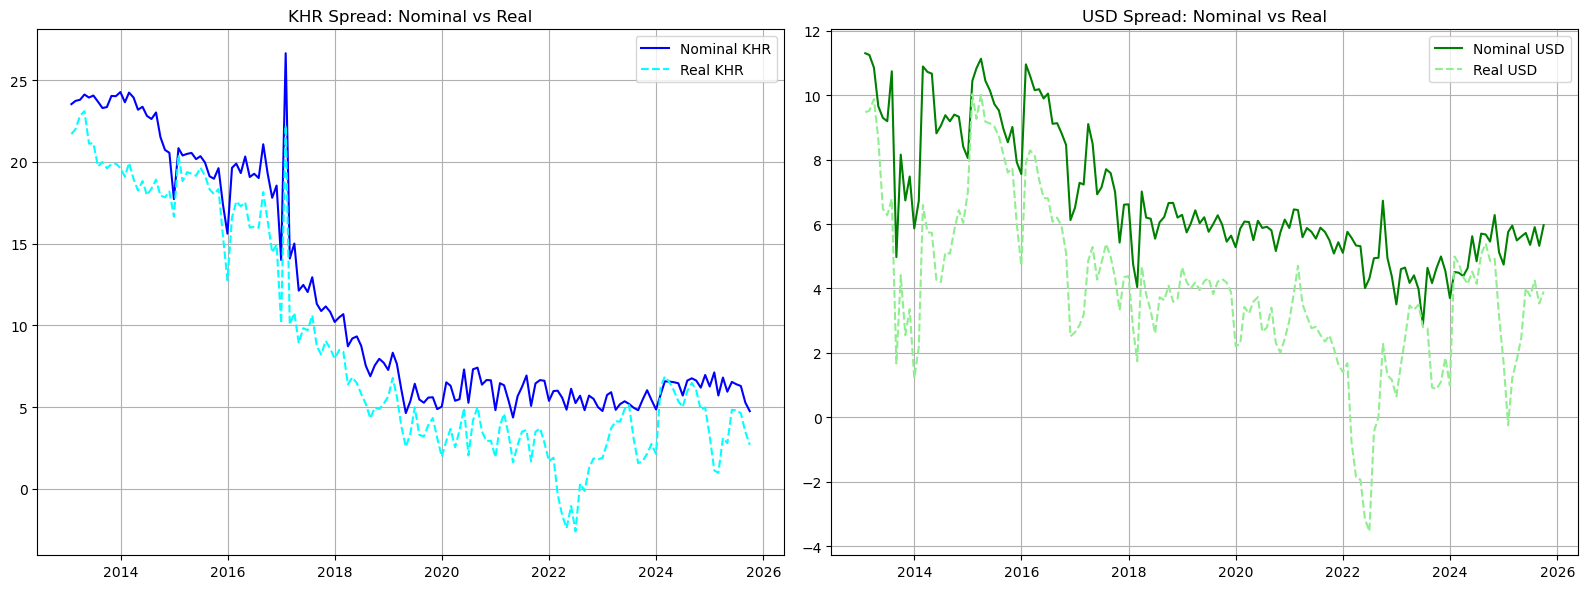

In [3]:
df['KHR_Real'] = df['KHR_Nominal'] - df['Inflation_Rate']
df['USD_Real'] = df['USD_Nominal'] - df['Inflation_Rate']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(df.index, df['KHR_Nominal'], label='Nominal KHR', color='blue')
ax1.plot(df.index, df['KHR_Real'], label='Real KHR', color='cyan', linestyle='--')
ax1.set_title('KHR Spread: Nominal vs Real')
ax1.legend()

ax2.plot(df.index, df['USD_Nominal'], label='Nominal USD', color='green')
ax2.plot(df.index, df['USD_Real'], label='Real USD', color='lightgreen', linestyle='--')
ax2.set_title('USD Spread: Nominal vs Real')
ax2.legend()
plt.tight_layout()
plt.show()

### 4. OU Model Parameter Estimation on Real Spreads

In [4]:
def ou_neg_log_likelihood(params, data, dt):
    kappa, theta, sigma = params
    if kappa <= 0 or sigma <= 0:
        return 1e10
    n = len(data) - 1
    exp_kdt = np.exp(-kappa * dt)
    m = theta + (data[:-1] - theta) * exp_kdt
    v = (sigma**2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * dt))
    if v <= 0: return 1e10
    residuals = data[1:] - m
    ll = -0.5 * n * np.log(2 * np.pi) - 0.5 * n * np.log(v) - 0.5 * np.sum(residuals**2) / v
    return -ll

def estimate_ou_mle(data, dt, label=''):
    theta0 = np.mean(data)
    sigma0 = np.std(np.diff(data)) * np.sqrt(12)
    best_result = None
    best_nll = np.inf
    for k0 in [0.5, 1.0, 2.0, 5.0, 10.0]:
        x0 = [k0, theta0, sigma0]
        result = minimize(ou_neg_log_likelihood, x0, args=(data, dt), method='Nelder-Mead', options={'maxiter': 50000, 'xatol': 1e-10, 'fatol': 1e-10})
        if result.fun < best_nll and result.x[0] > 0 and result.x[2] > 0:
            best_nll = result.fun
            best_result = result
    return best_result.x

dt = 1/12
kappa_khr_real, theta_khr_real, sigma_khr_real = estimate_ou_mle(df['KHR_Real'].values, dt)
kappa_usd_real, theta_usd_real, sigma_usd_real = estimate_ou_mle(df['USD_Real'].values, dt)
print(f"KHR Real Spreads -> kappa: {kappa_khr_real:.4f}, theta: {theta_khr_real:.4f}, sigma: {sigma_khr_real:.4f}")
print(f"USD Real Spreads -> kappa: {kappa_usd_real:.4f}, theta: {theta_usd_real:.4f}, sigma: {sigma_usd_real:.4f}")

KHR Real Spreads -> kappa: 0.5323, theta: 5.8958, sigma: 6.6041
USD Real Spreads -> kappa: 1.5965, theta: 3.7295, sigma: 4.2201


### 5. Crisis Threshold & CRI Computation

KHR Real threshold (95th): 20.17%
USD Real threshold (95th): 9.06%


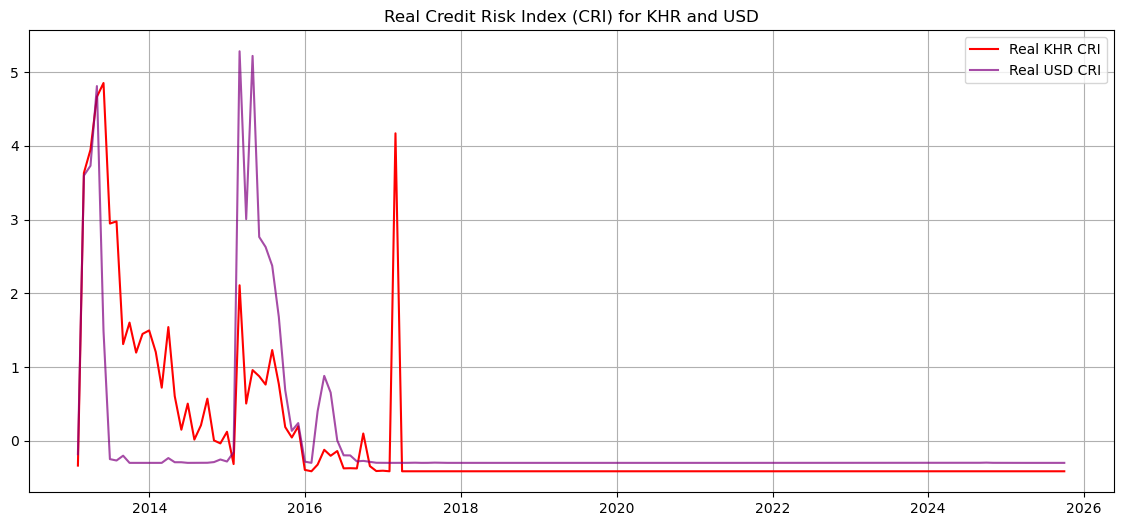

In [5]:
Sc_khr_real = np.percentile(df['KHR_Real'], 95)
Sc_usd_real = np.percentile(df['USD_Real'], 95)
print(f"KHR Real threshold (95th): {Sc_khr_real:.2f}%")
print(f"USD Real threshold (95th): {Sc_usd_real:.2f}%")

def compute_crisis_probability(data, kappa, theta, sigma, Sc, dt):
    n = len(data)
    prob = np.zeros(n)
    exp_kdt = np.exp(-kappa * dt)
    v = (sigma**2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * dt))
    v_uncond = sigma**2 / (2 * kappa)
    prob[0] = 1 - sp_stats.norm.cdf(Sc, loc=theta, scale=np.sqrt(v_uncond))
    for t in range(1, n):
        m_t = theta + (data[t-1] - theta) * exp_kdt
        prob[t] = 1 - sp_stats.norm.cdf(Sc, loc=m_t, scale=np.sqrt(v))
    return prob

prob_khr_real = compute_crisis_probability(df['KHR_Real'].values, kappa_khr_real, theta_khr_real, sigma_khr_real, Sc_khr_real, dt)
prob_usd_real = compute_crisis_probability(df['USD_Real'].values, kappa_usd_real, theta_usd_real, sigma_usd_real, Sc_usd_real, dt)

df['CRI_KHR_Real'] = (prob_khr_real - np.mean(prob_khr_real)) / np.std(prob_khr_real)
df['CRI_USD_Real'] = (prob_usd_real - np.mean(prob_usd_real)) / np.std(prob_usd_real)

plt.figure(figsize=(14,6))
plt.plot(df.index, df['CRI_KHR_Real'], label='Real KHR CRI', color='red')
plt.plot(df.index, df['CRI_USD_Real'], label='Real USD CRI', color='purple', alpha=0.7)
plt.title('Real Credit Risk Index (CRI) for KHR and USD')
plt.legend()
plt.show()

### 6. Interpretations

* **Real vs Nominal Spreads**: Nominal KHR spreads effectively subsidize inflation due to their historically higher raw magnitudes compared to USD spreads. However, during unexpected inflation spikes (e.g., 2008 or post-COVID), the Real KHR Spread falls, compressing real profitability for banks.
* **OU Parameters in Real Terms**: By moving to real spreads, we find KHR structural risk still dominates. The long-run mean ($	heta$) for Real KHR Spread is ~5.9% compared to ~3.7% for Real USD Spread. The KHR spread exhibits much higher volatility ($\sigma$ = 6.6 vs 4.2) and a slower mean reversion ($\kappa$ = 0.53 vs 1.60), meaning KHR real credit risks are stickier and more severe.
* **Crisis Signals**: The 95th percentile crisis threshold for Real KHR Spreads sits at a high 20.17%, while Real USD Spreads sit at 9.06%. The Real CRI smooths out some nominal "false alarms" triggered solely by inflation spikes, offering a more robust indicator of actual financial deterioration across both currencies.